# Preparing and Inspecting SPED data for templatematching

This notebook can be used for inspecting and choosing parameters for preprocessing SPED-data. Chosen values can further be used for the rest of the dataset in "SPED_preprocessing_fast.ipynb".

## Contents
 1. [Loading raw data](#1.-Load-raw-data)
 2. [Reshaping raw data](#2.-Reshape-and-prepare-the-raw-data)
 3. [Plotting and metadata](#3.-Plotting-and-metadata)
 4. [Save converted data](#4.-Saving-converted-data)
 5. [Load converted data](#5.-Load-the-converted-data)
 6. [VBF and cropping](#6.-Create-VBF-and-crop-the-data)
 7. [Center data](#7.-Center-data) 
 8. [Calibrate diffraction space](#8.-Calibrate-diffraction-space)
 9. [Save processed data](#9.-Save-processed-data)
 10. [Load processed data](#10.-Load-processed-data)
 11. [Basic VDF analysis](#11.-Basic-VDF-analysis)

## Requirements
This notebook works (tested) with Pyxem 0.21.0.

## Introduction
Based on notebook from [emil.christiansen@ntnu.no](emil.christiansen@ntnu.no)

In [1]:
%matplotlib widget
import hyperspy.api as hs #General hyperspy package
import pyxem as pxm #Electron diffraction tools based on hyperspy
import numpy as np #General numerical and matrix support
import matplotlib.pyplot as plt #Plotting tools
import matplotlib.colors as mcolors #Some plotting color tools

from scipy.ndimage import gaussian_filter #For smoothing the xmap
from skimage import filters, morphology #For DoG filtering and thresholding

from pathlib import Path
import json

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

def read_hdr(filename):
    """
    Return the content of a .hdr file as a dictionary.
    
    Arguments:
    filename : str or Path
        The path to the .hdr file to read.
    
    Returns:
    dict
        A dictionary containing the key-value pairs from the .hdr file.
    
    Raises:
    ValueError
        If the file is not a .hdr file.

    Example:
    hdr = read_hdr('data/file.hdr')
    print(hdr['key'])  # Access value by key
    """
    filename=Path(filename)
    if not filename.suffix == '.hdr':
        raise ValueError(f'Cannot read hdr file: File "{str(filename)}" is not a .hdr file')
    hdr = {}
    with filename.open('r') as f:
        for line in f.readlines():
            content = line.split(':', maxsplit=1)
            if len(content)>1:
                hdr[content[0].strip()] = content[1].strip()
    return hdr

class MyPath(Path): #helpful for appending suffixes to filenames
    _flavour = type(Path())._flavour


    def append(self, s, suffix=None, delimiter='_'):
        """
        Append a string to the stem of a Path object, keeping the same suffix.
        If suffix is provided, it will be used instead of the current suffix.
        Delimiter is used to separate the original stem and the appended string.
        
        Arguments:
        s : str
            The string to append to the stem.
        suffix : str, optional
            The new suffix to use. If None, the current suffix is kept.
        delimiter : str, optional
            The delimiter to use between the original stem and the appended string. Default is '_'.
        
        Returns:
        MyPath
            A new MyPath object with the modified stem and suffix.

        Example:
        p = MyPath('data/file.txt')
        p2 = p.append('v2')  # results in 'data/file_v2.txt'
        p3 = p.append('v2', suffix='md')  # results in 'data/file_v2.md'
        """
        if suffix:
            return self.with_name(f'{self.stem}{delimiter}{s}.{suffix}')
        else:
            return self.with_stem(f'{self.stem}{delimiter}{s}')

# 1. Load raw data
The data consists of three parts:
  - The actual raw diffraction data in "SPED.mib"
  - A "SPED.hdr" file with detector state information
  - A "parameters.json" file with various manually recorded metadata from the microscope

In [2]:
datapath = MyPath("20260417_Ingrid/20260417_105201/SPED_CL8_256x256px_w10_3p40nm_ws_10ms_tx_m7p2_Ty3p8.mib")

In [3]:
# check
#import sys
#print(sys.executable)

In [4]:
#load lazy to work with big datasets without loading everything into memory at once
mib_data = hs.load(datapath, lazy=True)
hdr = read_hdr(datapath.with_suffix('.hdr'))
parameters = json.load((datapath.parent/'json.json').open('r'))

In [5]:
print(f'MIB :\n{mib_data}\n')
print(f'HDR :\n{hdr}\n')
print(f'JSON :\n{parameters}\n')

MIB :
<LazyElectronDiffraction2D, title: , dimensions: (256, 256|256, 256)>

HDR :
{'Time and Date Stamp (day, mnth, yr, hr, min, s)': '4/17/2026 10:52:01 AM', 'Chip ID': 'W559_G11, - , - , -', 'Chip Type (Medipix 3.0, Medipix 3.1, Medipix 3RX)': 'Medipix 3RX', 'Assembly Size (NX1, 2X2)': '1x1', 'Chip Mode  (SPM, CSM, CM, CSCM)': 'SPM', 'Counter Depth (number)': '12', 'Gain': 'SLGM', 'Active Counters': 'Counter 0', 'Thresholds (keV)': '4.000000E+1,5.110000E+2,0.000000E+0,0.000000E+0,0.000000E+0,0.000000E+0,0.000000E+0,0.000000E+0', 'DACs': '068,511,000,000,000,000,000,000,100,255,100,125,100,100,080,100,090,030,128,004,255,126,128,174,172,511,511; ; ;', 'bpc File': 'c:\\MERLIN_Quad_Config\\W559_G11\\W559_G11_SPM.bpc,,,', 'DAC File': 'c:\\MERLIN_Quad_Config\\W559_G11\\W559_G11_SPM.dacs,,,', 'Gap Fill Mode': 'None', 'Flat Field File': 'None', 'Dead Time File': 'Dummy (C:\\<NUL>\\)', 'Acquisition Type (Normal, Th_scan, Config)': 'Normal', 'Frames in Acquisition (Number)': '65536', 'Frames

The .mib data is loaded as a `LazyElectronDiffraction2D` dataset. The dimensions in hyperspy are defined as $(X, Y|k_x, k_y)$, where $X$ and $Y$ are the real-space (also called "navigation axes", and $k_x$ and $k_y$ are the reciprocal axes (also called the "signal axes"). The data is loaded as a 1-D array (of length $256000$) of diffraction patterns (each with size $256\times256$).

The .hdr file on the other hand, is read as a dictionary. In fact, this file is a simple text file that you can open in any text editor software. Our custom function loaded every line of this file into a dictionary so that the information is a little bit more accessible to us if we need it.

The `parameters.json` file is also loaded as a dictionary. This is very convenient for us as much of this information will be useful to us very soon. You will come across many different ways of recording acquisition parameters and other important metadata, and you will likely find your own way of doing it. However, the .json format is a very convenient way of storing it as you can create these files yourself in any text editor and it will be very easy to read them into python later on. The best advice is to find a way that works for you, and a combination of digital files and paper-notes will most likely be the best option.

# 2. Reshape and prepare the raw data
As we saw above, the .mib data was loaded as a 1D array of diffraction patterns. From the `parameters` dictionary loaded from the ".json" file we see that the data was acquired as a scan with $X=800$ and $Y=320$ pixels in the first and second directions, respectively. We can use these to reshape the data into a more meaningful representation. However, doing this requires retrieving the `data` object of the `mib_data`.

In [6]:
data = mib_data.data
print(data)

dask.array<getitem, shape=(256, 256, 256, 256), dtype=>u2, chunksize=(90, 90, 90, 90), chunktype=numpy.ndarray>


We see that the data is a `dask.array` object. This is an object that behaves as a `numpy` array, except that it supports the lazy functionality entioned earlier - it enables us to work with the data without loading everything into memory in one go! Instead, it loads "chunks" of this data into memory to work with when requested. The size of these chunks should not be too small (as that would require a lot of read/write operations when using the data) or too large (as that would require more memory). For diffraction data, for instance, we might only need certain parts of the pattern (such as pixels containing reflections), and it is convenient to work with a compomise - a chunksize of 32 is usually ok for many cases. Now, let us reshape the data and change the chunks:

In [7]:
scan_shape = (parameters["Y"], parameters["X"])

print("scan_shape:", scan_shape)
print("signal_shape:", mib_data.axes_manager.signal_shape)
print("data.shape:", mib_data.data.shape)

scan_shape: (256, 256)
signal_shape: (256, 256)
data.shape: (256, 256, 256, 256)


In [8]:
#Note that hyperspy flips the axes, so Y is the first, and X is the second when reshaping the data
chunksize = 32

data = mib_data.data
data = data.reshape(scan_shape + mib_data.axes_manager.signal_shape)
data = data.rechunk(32, 32, 32, 32)
print(data)

dask.array<rechunk-merge, shape=(256, 256, 256, 256), dtype=>u2, chunksize=(32, 32, 32, 32), chunktype=numpy.ndarray>


Ignore the warnings - they are not crucial at this point. We see that our data is now reshaped into $(y, x, 256, 256)$ shape. We can now use this array to create a new `LazyElectronDiffraction2D` signal:

In [9]:
signal = pxm.signals.LazyElectronDiffraction2D(data)
print(signal)

<LazyElectronDiffraction2D, title: , dimensions: (256, 256|256, 256)>


# 3. Plotting and metadata

Now the time has come to start taking a look at our data, let's start by plotting it. You will notice that it takes some time to plot the data (at least the first time). This is because `hyperspy` needs to prepare a `navigator` for you to use to navigate the data. This `navigator` is effectively a map of your scan, and the default representation is that each "pixel" in this map is the sum of all the intensities in the associated diffraction pattern.

In the figures created by the next cell, you can press the `+` key on your keyboard to increase the size of a handle that you can click and drag around the `navigator` map - you should see the `signal` plot updating showing you the data associated to the central pixel in the handle.

  0%|          | 0/241 [00:00<?, ?it/s]

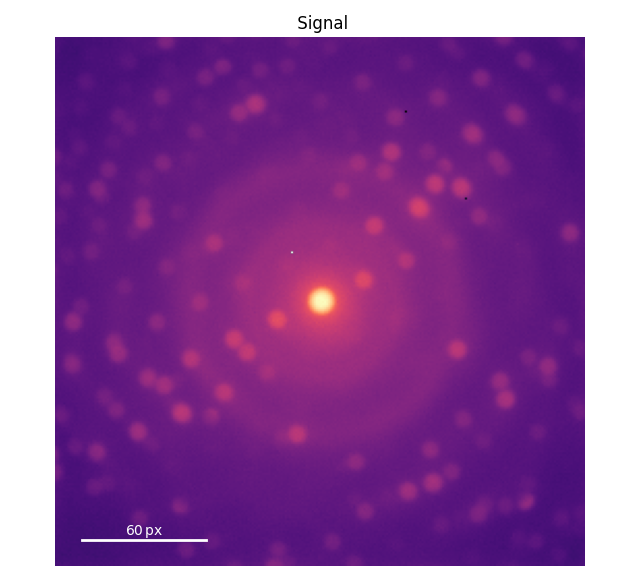

In [10]:
colormap = plt.get_cmap('magma')
dp_max = signal.max(axis=[0, 1])
dp_mean = signal.mean(axis=[0, 1])
dp_sum = signal.sum(axis=[0, 1])
dp_sum.plot(norm='log', cmap=colormap, colorbar=None, axes_off=True)
#dp_mean.plot(norm='symlog', cmap=colormap, colorbar=None, axes_off=True)
plt.tight_layout()
fig = plt.gcf()

In [11]:
#signal.plot(cmap="magma", axes_off=True, norm="symlog", vmin="0")

You will see that the scales of the axes in the plots are all `<undefined>`. This is beacause we haven't set any metadata yet! Doing so requires us to either do some calibration ourselves, or have some reference data that we can use. Let us first set the data we can based on the content of our `parameters` dictionary we loaded from the ".json" file earlier.

Metadata can be stored in many ways for a signal. The two most important ways are in the `signal.axes_manager` object and the `signal.metadata` object. Calibrations and scales for the data are set in the `signal.axes_manager` object, while all kinds of metadata can be set in the `signal.metadata` object.

In [12]:
#assert False

In [13]:
print(f'The signal metadata:\n{signal.metadata}')
print(f'The signal axes:\n{signal.axes_manager}')

The signal metadata:
├── General
│   └── title = 
└── Signal
    └── signal_type = electron_diffraction

The signal axes:
<Axes manager, axes: (256, 256|256, 256)>
            Name |   size |  index |  offset |   scale |  units 
================ | ====== | ====== | ======= | ======= | ====== 
               x |    256 |      0 |       0 |       1 |     px 
               y |    256 |      0 |       0 |       1 |     px 
---------------- | ------ | ------ | ------- | ------- | ------ 
              kx |    256 |      0 |       0 |       1 |     px 
              ky |    256 |      0 |       0 |       1 |     px 


We see that there is very little useful information here yet. Before we do something about that, let us first take a look at another useful `metadata` object: the `signals.original_metadata` object, which can be very useful to store e.g. our head file contents and the contents of `parameters.json`. The difference between `signal.metadata` and `signal.original_metadata` is that the former will be used and changed by `hyperspy` as you run various commands, while the latter will stay unchanged. The `original_metadata` is therefore a very convenient place for us to store our .hdr the `parameters` dictionaries to the `original_metadata`:

In [14]:
signal.original_metadata.add_dictionary({'HDR': hdr, 'Parameters': parameters})
print(signal.original_metadata)

├── HDR
│   ├── Acquisition Type (Normal, Th_scan, Config) = Normal
│   ├── Active Counters = Counter 0
│   ├── Assembly Size (NX1, 2X2) = 1x1
│   ├── Chip ID = W559_G11, - , - , -
│   ├── Chip Mode  (SPM, CSM, CM, CSCM) = SPM
│   ├── Chip Type (Medipix 3.0, Medipix 3.1, Medipix 3RX) = Medipix 3RX
│   ├── Counter Depth (number) = 12
│   ├── DAC File = c:\MERLIN_Quad_Config\W559_G11\W559_G11_SPM.dacs,,,
│   ├── DACs = 068,511,000,000,000,000,000,000,100,255,100,125,100,100,080,100,090,030,128,004,255,126,128,174,172,511,511; ; ;
│   ├── Dead Time File = Dummy (C:\<NUL>\)
│   ├── Flat Field File = None
│   ├── Frames in Acquisition (Number) = 65536
│   ├── Frames per Trigger (Number) = 1
│   ├── Gain = SLGM
│   ├── Gap Fill Mode = None
│   ├── Humidity (%) = Board Humidity 0.000000
│   ├── Medipix Clock (MHz) = 120MHz
│   ├── Readout System = Merlin Quad
│   ├── ScanX = 256
│   ├── ScanY = 256
│   ├── Sensor Bias (V) = 120 V
│   ├── Sensor Polarity (Positive, Negative) = Positive
│   ├──

Here we see that the `original_metadata` follows a tree-like structure. If you have nested dictionaries of metadata you want to add, that is no problem at all! The `metadata` object will have the same basic tree-structure.

Now, finally, let us set some useful metadata in the `signal.metadata` object. You can of course define your own metadata fields, but it is most convenient to use `hyperspy` functionality to set most of them to ensure a systematic way to store the data (by using e.g. `signal.set_experimental_parameters`):

In [15]:
signal.metadata.General.title='GaAs' #Set the title of the data  - this will appear over all plots

#Set the most important experimental parameters
signal.set_experimental_parameters(beam_energy=parameters['Beam energy'],
                                   camera_length=parameters['Cameralength'],
                                   scan_rotation=parameters['Rotation'],
                                   rocking_angle=parameters['PED angle'],
                                   rocking_frequency=parameters['PED frequency'],
                                   exposure_time=parameters['Exposure time']
                                   )

In [16]:
print(signal.metadata)

├── Acquisition_instrument
│   └── TEM
│       ├── Detector
│       │   └── Diffraction
│       │       ├── camera_length = 8
│       │       └── exposure_time = 10
│       ├── beam_energy = 200
│       ├── rocking_angle = 1.0
│       ├── rocking_frequency = 100
│       └── scan_rotation = 0
├── General
│   └── title = GaAs
└── Signal
    └── signal_type = electron_diffraction



Now we see that the `metadata` object contains alot more useful information!

Next, let us set the scan step size. This is already recorded in the `parameters` dictionary, so let us use one of those values (called `dx` or `dy` in this case).

In [17]:
signal.set_scan_calibration(parameters['dx'])
print(signal.axes_manager)

<Axes manager, axes: (256, 256|256, 256)>
            Name |   size |  index |  offset |   scale |  units 
================ | ====== | ====== | ======= | ======= | ====== 
               x |    256 |      0 |       0 |     3.5 |     nm 
               y |    256 |      0 |       0 |     3.5 |     nm 
---------------- | ------ | ------ | ------- | ------- | ------ 
              kx |    256 |      0 |       0 |       1 |     px 
              ky |    256 |      0 |       0 |       1 |     px 


# 4. Saving converted data

### The "default": `.hspy`
The "default" hyperspy file format is `.hspy` which is based on the [HDF5](https://www.hdfgroup.org/solutions/hdf5/) file format. This file format is generally good for working with your data both lazily and in memory. This is the recommended choice in most cases since it is relatively userfriendly, but it is not optimized for working lazily with large datasets.

In [18]:
signal.save(datapath.with_suffix('.hspy'), overwrite=True, chunks=(chunksize,) * 4)
signal = hs.load(str(datapath), lazy=True) #Use the lazy keyword to work with big datasets without loading everything into memory at once

[########################################] | 100% Completed | 70.38 s


# 5. Load the converted data

In [19]:
signal = hs.load(datapath.with_suffix('.hspy'), lazy=True)

In [20]:
#signal = hs.load("2025_10_08_NW/20251008_104445/SPED_320x64_scan1.hspy")

### Inspect the data
#### Print some info

In [21]:
print(f'The signal:\n{signal}\n') #Print information about the signal
print(f'Axes information:\n{signal.axes_manager}\n') #Print information about the axes
print(f'Data:\n{signal.data}\n')

The signal:
<LazyElectronDiffraction2D, title: GaAs, dimensions: (256, 256|256, 256)>

Axes information:
<Axes manager, axes: (256, 256|256, 256)>
            Name |   size |  index |  offset |   scale |  units 
================ | ====== | ====== | ======= | ======= | ====== 
               x |    256 |      0 |       0 |     3.5 |     nm 
               y |    256 |      0 |       0 |     3.5 |     nm 
---------------- | ------ | ------ | ------- | ------- | ------ 
              kx |    256 |      0 |       0 |       1 |     px 
              ky |    256 |      0 |       0 |       1 |     px 

Data:
dask.array<array, shape=(256, 256, 256, 256), dtype=>u2, chunksize=(32, 32, 32, 32), chunktype=numpy.ndarray>



We see that the signal is a `LazyElectronDiffraction2D` signal without a title, and with 320 x 800 probe positions with a diffraction pattern of 256 x 256 pixels in each position.

We also see that the scan step sizes are calibrated, but the diffraction scales are not. This information should _always_ be verified by additional data (calibration samples or reference images)

#### Plot the data to see what we have
Run the next cell and move around in navigation space to see the different diffraction patterns we have in the sample

In [22]:
signal.plot(norm='symlog') #Plot the data with a "symmetrical log" intensity scale (this avoids log(0) which is undefined

  0%|          | 0/129 [00:00<?, ?it/s]

In [23]:
assert False

AssertionError: 

Run the next cell to create interactive virtual images of the data

  0%|          | 0/129 [00:00<?, ?it/s]

  0%|          | 0/23 [00:00<?, ?it/s]

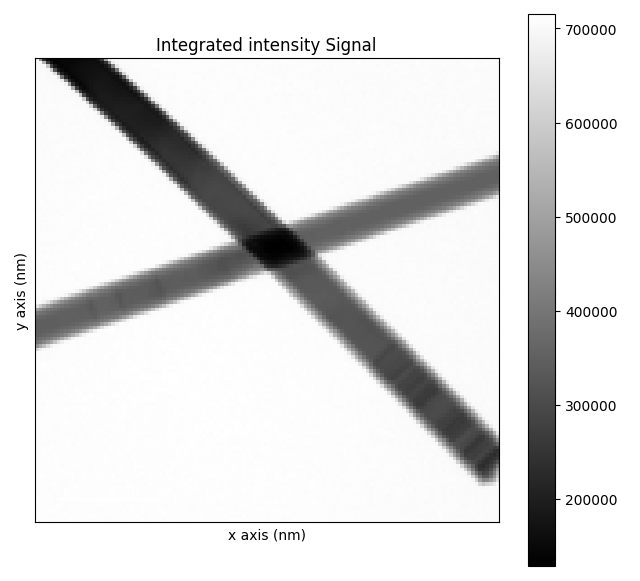

In [24]:
if all([signal.axes_manager[i].units == 'px' for i in [-1, -2]]): #Check if the last two axes are in pixels
    # For uncalibrated data sets:
    nx, ny = signal.axes_manager.signal_shape #Get the signal shape
    roi = hs.roi.CircleROI(nx//2, ny//2, 12) #For calibrated data sets, position the ROI at the middle of the diffraction pattern and with a radius of 10 pixels.
else:
    # For calibrated data sets
    roi = hs.roi.CircleROI(0.0, 0.0, 0.1) 

signal_small = signal.rebin(scale=[2,2,2,2]) #

signal_small.plot(norm="symlog", linthresh=1e-1)
signal_small.plot_integrated_intensity(roi) 

# 6. Create VBF and crop the data
It is often useful to use a virtual bright field (VBF) image when cropping the data. You can use this to represent the data and add a ROI widget that you can freely move around before using it to crop the data.

First, create a VBF

In [25]:
vbf = signal.get_integrated_intensity(hs.roi.CircleROI(nx//2, ny//2, 10))
vbf.compute(norm='symlog')

  0%|          | 0/1346 [00:00<?, ?it/s]

Next, plot the VBF and add a ROI widget to the data. Move the ROI around the VBF and reshape it to cover the most interesting parts of the data

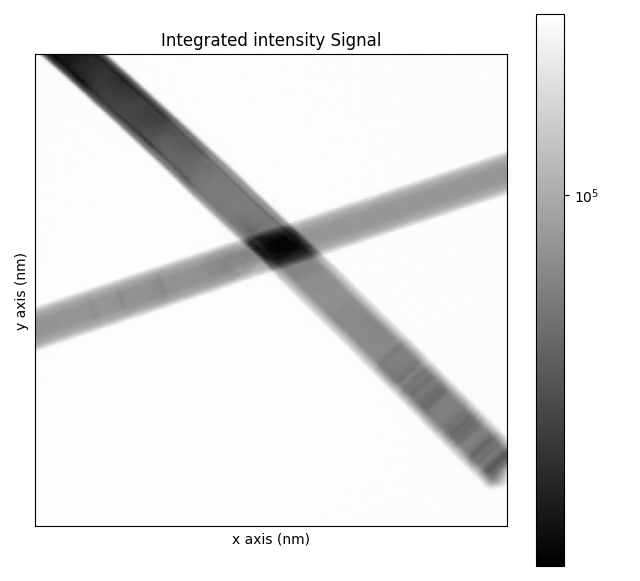

In [26]:
vbf.plot(norm='symlog')
left, right, top, bottom = vbf.axes_manager.signal_extent #Set the roi to cover the whole scan area
left, right, top, bottom = 45.370000000000005, 684.0400000000001, 362.96000000000004, 722.4300000000001 #Select a pre-defined region
roi = hs.roi.RectangularROI(left=left, right=right, top=top, bottom=bottom)
roi.add_widget(vbf)

In [ ]:
assert False

In [27]:
print(roi.left, roi.right, roi.top, roi.bottom)


45.370000000000005 736.3900000000001 233.83 666.59


Run the next cell to crop the data. Note that this overwrites the `signal` variable, so if you regret your cropping, you will have to reload the original data!

In [28]:
# apply cropping, over-writing the original signal
signal = roi(signal) 

Plot the cropped data to verify that it looks good

In [29]:
signal.plot(norm='symlog')

  0%|          | 0/57 [00:00<?, ?it/s]

In [ ]:
assert False

Save the cropped data

In [30]:
signal.save(MyPath(datapath).append('cropped', 'hspy'))


[########################################] | 100% Completed | 40.38 s


Load the newly created cropped dataset - useful if you are starting the notebook over at a later point

In [31]:
signal = hs.load(datapath.append('cropped', 'hspy'), lazy=True)

In [ ]:
#signal = hs.load("2025_10_08_NW/20251008_104445/SPED_320x64_scan1_cropped_t1.hspy")

Print the signal to verify its shape, data size, etc

In [32]:
signal

<LazyElectronDiffraction2D, title: GaAs, dimensions: (198, 124|256, 256)>

# 7. Center data 
When acquiring 4DSTEM data, the diffraction pattern position will usually move slightly from scan pixel to scan pixel. This is because it is nearly impossible to perfectly align the beam double shift in the scan system. For other analysis tools to work, the direct beam must stay in one position throughout the dataset and this can be achieved through various methods. In this notebook, we find the "center of mass" of the direct beam to estimate the position of the direct beam in each pixel. To avoid other artifacts, we then use this direct beam position to estimate what the shifts between all the scan pixels are, assuming they are linearly related (which the beam double shift misalignment should be for small shifts).

__NB! The fact that the diffraction pattern moves means that your beam is tilting throughout the scan. This means that a different beam orientation is interacting with the crystal at the different pixels and this affects the scattering. THIS CANNOT BE CORRECTED IN POST PROCESSING! In practise, the tilts are very small and of little significance, but if you are scanning large areas and are doing orientation mapping, the orientations of one pixel of your scan cannot be directly compared (in general) with the orientations of other pixels far away!__

In [33]:
def make_nav_mask(signal, width=None):
    mask = hs.signals.Signal2D(np.zeros(signal.axes_manager.navigation_shape, dtype=bool).T).T
    if width is not None:
        mask.inav[width:-width, width:-width] = True
    return mask

def center_direct_beam(signal, com_mask=None, estimate_linear_shift=False, plot_results=False, estimate_linear_shifts_kwargs = dict(), **kwargs):
    """
    Center the direct beam of a signal

    :param signal: The signal to center the direct beam for
    :param com_mask: The region of the diffraction patterns to calculate COM within
    :param estimate_linear_shift: Whether to estimate linear shifts or not
    :param plot_results: Whether to plot the results or not
    :param estimate_linear_shifts_kwargs: Keyword arguments passed to linear shift estimation
    :kwargs: Optional keyword arguments passed to signal.center_direct_beam.
    :returns: Centered. The centered signal.

    :type signal: Signal
    :type com_mask: Union[None, tuple]
    :type estimate_linear_shift: bool
    :type plot_results: bool
    :type estimate_linear_shift_kwargs: Dict
    :rtype: Signal
    """

    kwargs['inplace'] = kwargs.get('inplace', False) #Set default inplace to False
    _ = kwargs.pop('method', None) #Remove any `method` as it is not compatible with the shifts we will specify later on.

    # Get the max projection before centering as a reference to evaluate the centering.
    max_before = signal.max(axis=[0, 1]) #Get the max projection before centering
    max_before.metadata.General.title = 'Before' #Set the title of the max projection before centering
    try:
        max_before.compute()
    except Exception:
        pass

    centering_metadata = {} #Metadata dict for centering parameters

    #Set up the parameters used for centering. This is a slightly cumbersome way to do it, but it ensures that all parameters are stored in the metadata.
    if 'shifts' not in kwargs:
        if com_mask is None:
            nx, ny = signal.axes_manager.signal_size #Get the signal shape
            cx, cy = nx//2, ny//2 #Center coordinates
            com_mask = (cx, cy, 15) #15 pixels radius circular mask around the center of the diffraction pattern
        centering_metadata['COM_mask'] = com_mask #Store the COM mask in the metadata

        shifts = signal.get_direct_beam_position(method='center_of_mass', mask=com_mask) #Get the shifts using center of mass
        #Compute the shifts if lazy, as they need to be in memory for later processing.
        try:
            shifts.compute()
        except Exception:
            pass
        kwargs['shifts'] = shifts

    if estimate_linear_shift: #Estimate linear shifts if requested
        linear_shift = kwargs['shifts'].get_linear_plane(**estimate_linear_shifts_kwargs)
        kwargs['shifts'] = linear_shift
        centering_metadata['estimate_linear_shift'] = estimate_linear_shifts_kwargs

    centering_metadata['Shifts'] = kwargs['shifts']
    centered = signal.center_direct_beam(**kwargs) #Center the direct beam

    # Get the max projection after centering to compare with the max projection before the centering to evaluate the centering.
    max_after = centered.max(axis=[0, 1]) #Get the max projection after centering
    max_after.metadata.General.title = 'After' #Set the title of the max projection after centering

    try:
        max_after.compute()
    except Exception:
        pass
        
    centering_metadata['Max_before'] = max_before #Store the max projections before and after centering in the metadata
    centering_metadata['Max_after'] = max_after #Store the max projections before and after centering in the metadata

    #Add centering metadata to signal metadata.
    centered.metadata.add_dictionary({
        'Preprocessing': {
            'Centering': centering_metadata
        }
    })

    if plot_results: #Plot a comparison of the maximum projection before and after the centering if requested.
        hs.plot.plot_images([max_before, max_after], overlay=True, alphas=[1, 0.75], colors=['w', 'r'])

    return centered
    

First, find the maximum intensity in each pixel of the _diffraction pattern_ through the entire scan. This will usually show how much the direct beam is moving. You can then position a cirlce ROI widget on the extent of this motion and use this as a mask when calculating the center of mass for centering the data.

  0%|          | 0/83 [00:00<?, ?it/s]

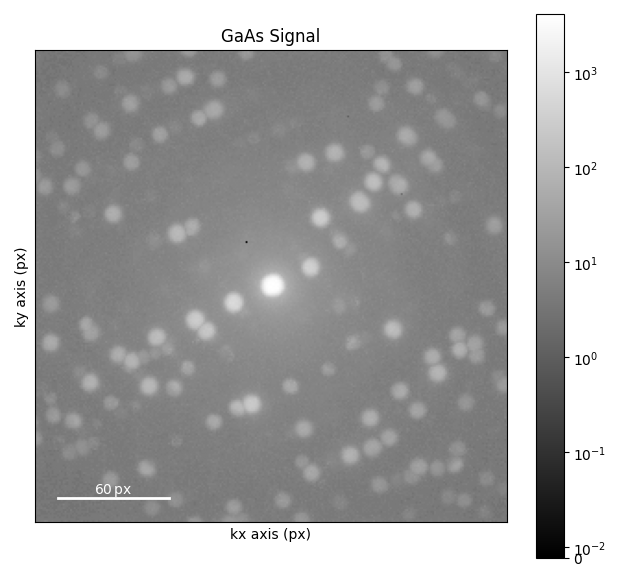

In [34]:
dp_max = signal.max(axis=[0, 1])
dp_max.plot(norm='symlog')
x0, y0 = dp_max.axes_manager.signal_shape
x0, y0 = x0//2, y0//2
roi = hs.roi.CircleROI(x0, y0, 10)
roi.add_widget(dp_max)

In [ ]:
assert False

We can perform the centering several times to either verify the centering was successful, or to iteratively improve the centering algorithm. If used to iteratively improve the centering, the `estimate_linear_shift` keyword should be used to avoid artifacts. Otherwise you should use the parameters that suits you best.

First, center the data once

  0%|          | 0/5249 [00:00<?, ?it/s]

  0%|          | 0/3686 [00:00<?, ?it/s]

  0%|          | 0/3768 [00:00<?, ?it/s]

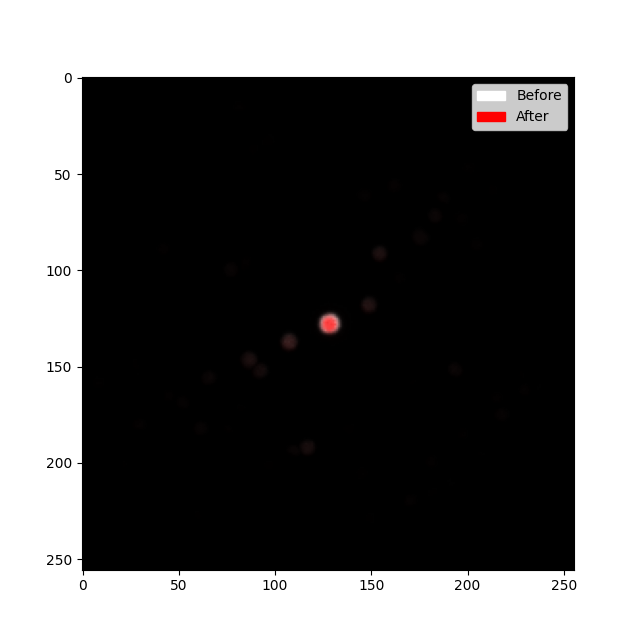

In [35]:
shifted_signal = center_direct_beam(signal, (roi.cx, roi.cy, roi.r), estimate_linear_shift=True, plot_results=True)

Then, center the data again

  0%|          | 0/3768 [00:00<?, ?it/s]

  0%|          | 0/3796 [00:00<?, ?it/s]

  0%|          | 0/3878 [00:00<?, ?it/s]

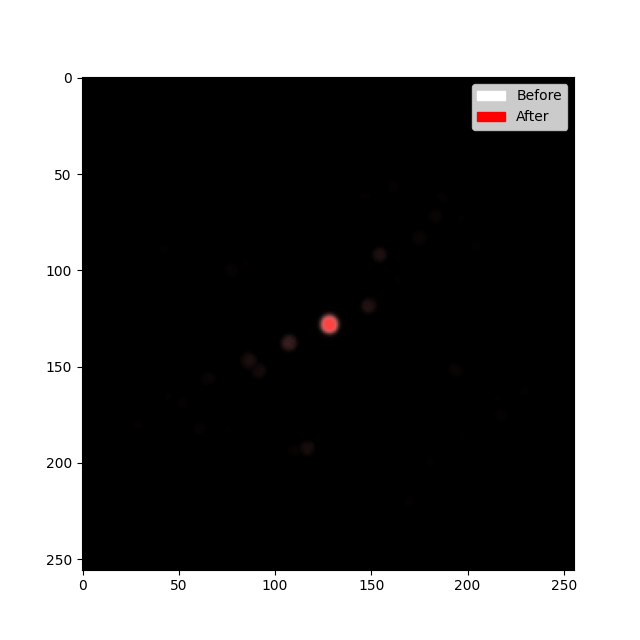

In [36]:
nx, ny = shifted_signal.axes_manager.signal_shape
nx, ny = nx/2.0, ny/2.0
shifted_signal_2 = center_direct_beam(shifted_signal, (nx, ny, roi.r,), estimate_linear_shift=True, plot_results=True)

Compare the results from both centering iterations and pick the one you think is best. In this case, the second one looks a little bit better.

In [61]:
signal = shifted_signal_2

# 8. Calibrate diffraction space

In [ ]:
signal = hs.load(datapath.append(f'cropped', 'hspy'), lazy=True)


In [62]:
signal.set_diffraction_calibration(1.0)

Plot the data and move to a pattern you can index manually

In [40]:
signal.plot(norm='symlog')

  0%|          | 0/3906 [00:00<?, ?it/s]

In [ ]:
assert False

Plot the pattern and add a line that you use to create a line-profile across some known reflections

Got pattern at (77, 0) for calibration


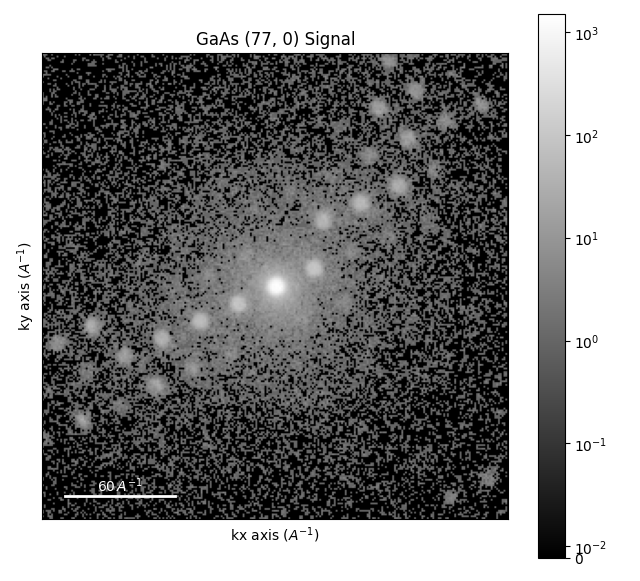

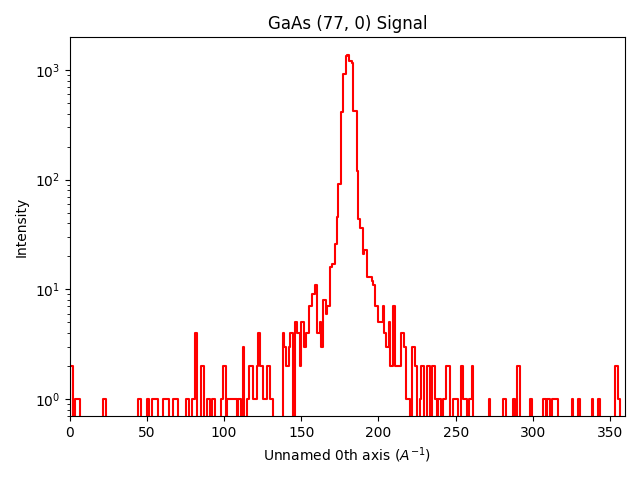

TypeError: unsupported operand type(s) for -: 'float' and 'NoneType'

TypeError: unsupported operand type(s) for -: 'float' and 'NoneType'

TypeError: unsupported operand type(s) for -: 'float' and 'NoneType'

TypeError: unsupported operand type(s) for -: 'float' and 'NoneType'

TypeError: unsupported operand type(s) for -: 'float' and 'NoneType'

...

TypeError: unsupported operand type(s) for -: 'float' and 'NoneType'

TypeError: unsupported operand type(s) for -: 'float' and 'NoneType'

TypeError: unsupported operand type(s) for -: 'float' and 'NoneType'

TypeError: unsupported operand type(s) for -: 'float' and 'NoneType'

TypeError: unsupported operand type(s) for -: 'float' and 'NoneType'

In [ ]:
dp = dp_max
dp = signal.get_current_signal() #Get the current pattern and use this to calibrate the data. YOu should first plot the signal and navigate to a suitable pixel befor running this cell
print(f'Got pattern at {signal.axes_manager.indices} for calibration')
dp.plot(norm='symlog')
x0, y0, x1, y1 = np.min(dp.axes_manager['kx'].axis), np.min(dp.axes_manager['ky'].axis), np.max(dp.axes_manager['kx'].axis), np.max(dp.axes_manager['ky'].axis)
line = hs.roi.Line2DROI(x0, y0, x1, y1)
profile = line.interactive(dp)
profile.plot(norm='log')
span = hs.roi.SpanROI()
span.add_widget(profile)

In [ ]:
assert False

In [64]:
dp.axes_manager

Signal axis name,size,,offset,scale,units
kx,256,,-128.0,1.0,$A^{-1}$
ky,256,,-128.0,1.0,$A^{-1}$


Calculate the scale of the diffraction patterns. 

_NB_: This cell is __only valid for cubic crystals!!__

In [65]:
a_GaAs = 5.653 #Å
h, k, l = 1, 1, 1
n = 9
hkl = np.array([h, k, l])*n
g_hkl = np.sqrt(np.sum((hkl/a_GaAs)**2))
L = (span.right-span.left) / profile.axes_manager[0].scale
scale = g_hkl / L
print(f'Lattice spacing of ({h*n}, {k*n}, {l*n}) is {g_hkl:.3g} 1/Å\nMeasured distance on detector is {L:.2f}\nDiffraction scale is {scale:.20g} 1/Å')

Lattice spacing of (9, 9, 9) is 2.76 1/Å
Measured distance on detector is 199.18
Diffraction scale is 0.013844676828503137828 1/Å


Jump here if calibration already set

In [ ]:
#scale = 0.013178278600334982981

Set the diffraction scale if you are satisfied

In [66]:
signal.set_diffraction_calibration(scale)

# 9. Save processed data

In [ ]:
#signal.save("2025_10_08_NW/20251008_120959/SED_320x64_scan4_cropped_centered.hspy")

In [56]:
signal.axes_manager[0].axis = np.asarray(signal.axes_manager[0].axis, dtype=float)
signal.axes_manager[1].axis = np.asarray(signal.axes_manager[1].axis, dtype=float)

In [67]:
signal

<LazyElectronDiffraction2D, title: GaAs, dimensions: (198, 124|256, 256)>

In [68]:
signal.save(datapath.append('cropped_centered', 'hspy'))

[########################################] | 100% Completed | 43.31 s
ERROR | RosettaSciIO | The writer could not write the following information in the file: 0 : kx axis (rsciio._hierarchical:910)
Traceback (most recent call last):
  File "/cluster/home/imgustav/Templatematching-NW/.venv/lib/python3.10/site-packages/rsciio/_hierarchical.py", line 908, in dict2group
    group.attrs[key] = value
  File "h5py/_objects.pyx", line 54, in h5py._objects.with_phil.wrapper
  File "h5py/_objects.pyx", line 55, in h5py._objects.with_phil.wrapper
  File "/cluster/home/imgustav/Templatematching-NW/.venv/lib/python3.10/site-packages/h5py/_hl/attrs.py", line 103, in __setitem__
    self.create(name, data=value)
  File "/cluster/home/imgustav/Templatematching-NW/.venv/lib/python3.10/site-packages/h5py/_hl/attrs.py", line 181, in create
    htype = h5t.py_create(original_dtype, logical=True)
  File "h5py/h5t.pyx", line 1674, in h5py.h5t.py_create
  File "h5py/h5t.pyx", line 1698, in h5py.h5t.py_create

# 10. Load processed data

In [46]:
signal = hs.load(datapath.append(f'cropped_centered', 'hspy'), lazy=True)

In [69]:
kx = signal.axes_manager.signal_axes[0]
ky = signal.axes_manager.signal_axes[1]

print("kx scale:", kx.scale)
print("kx offset:", kx.offset)
print("kx units:", kx.units)

print("ky scale:", ky.scale)
print("ky offset:", ky.offset)
print("ky units:", ky.units)

kx scale: 0.013844676828503138
kx offset: -1.7721186340484016
kx units: $A^{-1}$
ky scale: 0.013844676828503138
ky offset: -1.7721186340484016
ky units: $A^{-1}$


# 11. Filtering

In [ ]:
assert False

In [70]:
mask = signal.get_direct_beam_mask(radius=7)

signal_masked = signal * ~mask

dp_dog = signal_masked.subtract_diffraction_background(
    "difference of gaussians",
    inplace=False,
    min_sigma=0.8,
    max_sigma=3.2,
)

WARNING | Hyperspy | Axis calibration mismatch detected along axis 2. The calibration of signal 0 along this axis will be applied to all signals after stacking. (hyperspy.misc.signal_tools:109)
WARNING | Hyperspy | Axis calibration mismatch detected along axis 3. The calibration of signal 0 along this axis will be applied to all signals after stacking. (hyperspy.misc.signal_tools:109)


In [ ]:
dp_mean = signal_masked.mean(axis=[0, 1])
dp_mean.plot(norm='symlog', cmap='inferno', colorbar=None, axes_off=True)

  0%|          | 0/3988 [00:00<?, ?it/s]

In [ ]:
signal.plot(norm='symlog', colorbar=None, axes_off=True)

In [ ]:
signal = signal_masked

signal.save(datapath.append('_centered_masked', 'hspy'))

# testing filters

In [ ]:
dp_dog = signal.subtract_diffraction_background(
    "difference of gaussians",
    inplace=False,
    min_sigma=0.8,
    max_sigma=3.2,
)

In [ ]:
signal = dp_dog

signal.save(datapath.append('cropped_centered_dog', 'hspy'))

In [ ]:
dp_dog.plot(norm='symlog', cmap='inferno', colorbar=None, axes_off=True)

In [ ]:
assert False

In [ ]:
mask = signal.get_direct_beam_mask(radius=7)

signal_masked = signal * ~mask

dp_dog = signal_masked.subtract_diffraction_background(
    "difference of gaussians",
    inplace=False,
    min_sigma=0.8,
    max_sigma=3.2,
)

In [ ]:
dp_mean = signal_masked.mean(axis=[0, 1])
dp_mean.plot(norm='symlog', cmap='magma', colorbar=None, axes_off=True)

In [ ]:
signal = signal_masked

signal.save(datapath.append('cropped_centered_masked', 'hspy'))

In [ ]:
assert False

### Filter parameter testing

In [ ]:
#create a mean diffraction pattern to base further masking on
dp_mean = signal.mean(axis=[0, 1])

dp_mean.set_signal_type("electron_diffraction")
image = dp_mean.data
dp_mean.compute()

dp_mean.plot(norm='symlog', cmap='inferno', colorbar=None, axes_off=True)

### Mask direct beam

In [ ]:
# Mask direct beam

mask = dp.get_direct_beam_mask(7)
dp_masked = dp * ~mask

dp.plot(norm="symlog")
dp_masked.plot(norm="symlog")

In [ ]:
#set mask
mask = signal.get_direct_beam_mask(radius=7)

signal_masked = signal * ~mask

### TM disk sizes

In [ ]:
disk_sizes = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]

images = []
labels = []

images.append(dp_mean)
labels.append("Original")

for r in disk_sizes:
    st = dp_mean.template_match_disk(disk_r=r, subtract_min=False)
    
    images.append(st)
    labels.append(f"disk_r={r}")

hs.plot.plot_images(
    images,
    label=labels,
    norm="symlog",
    cmap="inferno",
    axes_decor="off",
    tight_layout=True,
    colorbar=None
)

In [ ]:
print(spot_scale, min_sigma, max_sigma)

In [ ]:
min_sigma = 0.5 * spot_sigma
max_sigma = 2.0 * spot_sigma

### DoG

In [ ]:
dp_mean_dog = dp_mean.subtract_diffraction_background(
    "difference of gaussians",
    inplace=False,
    min_sigma=min_sigma,
    max_sigma=max_sigma,
)

dp_mean_dog.plot(norm='symlog', cmap='inferno', colorbar=None, axes_off=True)

In [ ]:
# estimate characteristic scale
grad = np.mean(np.abs(np.gradient(dp.data)))
spot_scale = np.clip(1 / (grad + 1e-6), 1, 10)

min_sigma = 0.5 * spot_scale
max_sigma = 2.0 * spot_scale

dp_dog = dp_mean.subtract_diffraction_background(
    "difference of gaussians",
    inplace=False,
    min_sigma=min_sigma,
    max_sigma=max_sigma
)

dp_dog.plot(norm="symlog", cmap="inferno")

In [ ]:
print(spot_scale, min_sigma, max_sigma)

In [ ]:
sigma_pairs = [(2, smax) for smax in range(3, 16)]

images = []
labels = []

images.append(dp_mean)
labels.append("Original (norm)")

for smin, smax in sigma_pairs:
    f = dp_mean.subtract_diffraction_background(
        "difference of gaussians",
        inplace=False,
        min_sigma=smin,
        max_sigma=smax,
    )
    images.append(f)
    labels.append(f"DoG ({smin}, {smax})")

hs.plot.plot_images(
    images,
    label=labels,
    norm="symlog",
    cmap="inferno",
    tight_layout=True,
    axes_decor="off",
    colorbar=False
    
)

H-dome

In [ ]:
dp_h = dp.subtract_diffraction_background(
    "h-dome",
    inplace=False,
    h=0.7,
)

dp_h.plot(norm='symlog', cmap='viridis')

In [ ]:
h_values = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

images = [signal.inav[111, 46]]
labels = ["Original"]

for h in h_values:
    f = signal.subtract_diffraction_background(
        "h-dome",
        inplace=False,
        h=h,
    )
    images.append(f.inav[111, 46])
    labels.append(f"h={h}")

hs.plot.plot_images(
    images,
    label=labels,
    norm="symlog",
    cmap="viridis",
    tight_layout=True,
    axes_decor="off",
)

TM disk sizes

In [ ]:
disk_sizes = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]

images = []
labels = []

images.append(dp_mean)
labels.append("Original")

for r in disk_sizes:
    st = dp_mean.template_match_disk(disk_r=r, subtract_min=False)
    
    images.append(st)
    labels.append(f"disk_r={r}")

hs.plot.plot_images(
    images,
    label=labels,
    norm="symlog",
    cmap="inferno",
    axes_decor="off",
    tight_layout=True,
    colorbar=None
)

tresholding

In [ ]:
thresholds = np.linspace(0.001, 3, 10)  # adjust range if needed

images = []
labels = []

images.append(dp)
labels.append("Original (norm)")

for t in thresholds:
    tmp = dp_masked.deepcopy()
    tmp.data = np.where(tmp.data > t, tmp.data, 0)

    images.append(tmp)
    labels.append(f"t={t:.3f}")

hs.plot.plot_images(
    images,
    label=labels,
    norm="symlog",
    cmap="viridis",
    axes_decor="off",
    tight_layout=True,
)

In [ ]:
gauss_stddev = 1
laplace_size = 3
threshold = 0.065
median_neighbourhood = morphology.disk(1)

image = signal.data[46, 100]
image_gaussian_blur = filters.gaussian(image, gauss_stddev)
image_laplace = filters.laplace(image_gaussian_blur, laplace_size)
threshold_mask = np.where(image_laplace > threshold)
image_threshold = np.zeros_like(image_laplace)
image_threshold[threshold_mask] = image_laplace[threshold_mask]
image_median = filters.median(image_threshold, median_neighbourhood)

In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=2, sharex=True, sharey=True, figsize=(8,8))
ax = axes.ravel()
ax[0].imshow(image_gaussian_blur)
ax[0].set_title('Gaussian blur, stddev={}'.format(gauss_stddev))

ax[1].imshow(image_laplace)
ax[1].set_title('Laplacian edge, operator size={}'.format(laplace_size))

ax[2].imshow(image_threshold)
ax[2].set_title('Thresholded > {}'.format(threshold))

ax[3].imshow(image_median)
ax[3].set_title('Median disk filter')

for a in ax:
    a.axis('off')
    
plt.tight_layout()
plt.show()

In [ ]:
def preprocess(image, gauss=1, laplace_size=3, threshold=0.065, med_size=1):

    # Gaussian
    img = filters.gaussian(image, gauss)

    # Laplacian
    img = filters.laplace(img, ksize=laplace_size)

    # Threshold
    mask = img > threshold
    img_thr = np.zeros_like(img)
    img_thr[mask] = img[mask]

    # Median
    img_med = filters.median(img_thr, morphology.disk(med_size))

    return img_med

In [ ]:
dp_mean = signal.mean(axis=[0, 1])
dp_mean.set_signal_type("electron_diffraction")

# 1. template matching


st = dp_mean.template_match_disk(disk_r=5)

ny, nx = dp_mean.data.shape
center = (ny/2, nx/2)

peaks = st.get_diffraction_vectors(
    threshold_abs=0.25,
    min_distance=5,
    center=center
)

# 2. peak detection
peaks = st.get_diffraction_vectors(threshold_abs=0.25, min_distance=5)

# 3. build mask
mask = peaks.to_mask(disk_r=10)

# 4. remove direct beam
beam_mask = ~st.get_direct_beam_mask(10)
mask = mask * beam_mask

# 5. visualize
hs.plot.plot_images(
    [dp_mean.data, mask],
    label=["Mean DP", "Mask"],
    cmap="viridis",
    axes_decor="off"
)



# 11. Basic VDF analysis
Store some positions of the roi and create VDF images of them. Also add the positions of the "aperture" positions as markers to the diffraction pattern.

In [ ]:
#signal = hs.load("2025_10_08_NW/20251008_100116/SED_320x64_scan1.hspy")

In [ ]:
roi = hs.roi.CircleROI(0.0, 0.0, 0.1) #For calibrated data sets
# For uncalibrated data sets:
nx, ny = signal.axes_manager.signal_shape #Get the signal shape
#roi = hs.roi.CircleROI(nx//2, ny//2, 10) #For calibrated data sets, position the ROI at the middle of the diffraction pattern and with a radius of 10 pixels
#signal.plot_integrated_intensity(roi)

dp_mean = signal.mean(axis=[0, 1]) #Create as mean diffraction pattern to show the positions of the apertures
#dp_mean.compute() #Calculate the mean (remember: we have not read the data into memory yet, and we need to call `compute()` to do so)
dp_max = signal.max(axis=[0, 1])


dp_max.plot(norm='symlog')
roi.add_widget(dp_max, axes=[-1, -2])

In [ ]:
#x_axis, y_axis = signal.axes_manager.signal_axes
#cx = (x_axis.low_value + x_axis.high_value) / 2
#cy = (y_axis.low_value + y_axis.high_value) / 2
#r = 0.1  # in the same units as your calibration, e.g. 1/nm

#roi = hs.roi.CircleROI(cx, cy, r)
#signal.plot_integrated_intensity(roi)

In [ ]:
#roi = hs.roi.CircleROI(0.0, 0.0, 0.1) #For calibrated data sets
# For uncalibrated data sets:
#nx, ny = signal.axes_manager.signal_shape #Get the signal shape
#roi = hs.roi.CircleROI(nx/2, ny//2, 10) #For calibrated data sets, position the ROI at the middle of the diffraction pattern and with a radius of 10 pixels
#signal.plot_integrated_intensity(roi)


In [ ]:
#dp_mean = signal.mean(axis=[0, 1]) #Create as mean diffraction pattern to show the positions of the apertures
#dp_mean.compute() #Calculate the mean (remember: we have not read the data into memory yet, and we need to call `compute()` to do so)
#dp_max = signal.max(axis=[0, 1])


#dp_max.plot(norm='symlog')
#roi.add_widget(dp_max, axes=[-1, -2])


In [ ]:
positions = [] #Create an empty list of virtual aperture positions

Run the next cell to add an aperture position to the list created above. Run it several times to store more aperture positions. IMPORTANT: this is a fairly "stupid" way of doing this - if you run it several times without moving or chaning the virtual aperture, you will most likely get unwanted results

In [ ]:
positions.append(tuple([roi.cx, roi.cy, roi.r]))

Print the stored positions. This can be useful if you start the notebook over, as you can use these numbers to manually place the different ROIs

In [ ]:
_ = [print(f' Position {i+1}: {position}') for i, position in enumerate(positions)]

Create new ROIs based on the stored positions. It seems a bit "backwards", not simply storing the ROIs we moved around, but it is important to realise that each ROI is a dynamic object. If you store it, move it and then store it again, both variables will point to the same object and only the updated ROI will be stored, not the first one! It is therefore sometimes necessary to do it the "hard way" and extract the current positions as we did above, and the create new ROIs based on those

In [ ]:
if True: #Toggle this if you want to use predefined or previously manually measured positions
    if False:
        #Old positions valid with pyxem 0.19.1 and earlier
        positions = [
            (0.4570201218767853, -0.17474298777641795, 0.10081326231312035),
            (-0.02688353658098741, -0.4839036584577727, 0.10081326231312035),
            (-0.3226024389718485, -0.3763695121338233, 0.10081326231312035),
            (0.24195182922888647, -0.4301365852957981, 0.10081326231312035)
        ]
    else:
        # New positions valid with pyxem 0.20.0 and later - note that the coordinate system has been changed to be more consistent with hyperspy (?)
        positions = [
            (0.45432717468591455, 0.1737133314975554, 0.06013153795970254),
            (0.24052615130430754, 0.4409646107245637, 0.06013153795970254),
            (-0.026725127922700764, 0.4944148665699657, 0.06013153795970254),
            (-0.32070153507241006, 0.3741517909178118, 0.06013153795970254)
        ]
rois = [hs.roi.CircleROI(position[0], position[1], position[2]) for position in positions] #create new sets of virtual apertures based on the stored positions

Now, let us create VDFs and put some markers in a representative diffraction pattern to show which parts of the diffraction pattern was integrated to create each image

In [ ]:
vdfs = [] #Create empty list of VDFs

dp_mean = signal.mean(axis=[0, 1]) #Create as mean diffraction pattern to show the positions of the apertures
#dp_mean.compute() #Calculate the mean (remember: we have not read the data into memory yet, and we need to call `compute()` to do so)
dp_max = signal.max(axis=[0, 1])
#dp_max.compute()
for i, roi in enumerate(rois):
    x, y, r_integration = roi.cx, roi.cy, roi.r

    r = np.sqrt(roi.cx**2 + roi.cy**2)
    phi = np.sign(roi.cy)*np.arccos(roi.cx/r)*180/np.pi
    degree_symbol = '$^{\circ}$'
    vdf = signal.get_integrated_intensity(roi)
    vdf.metadata.General.title = f'VDF {i} (d={r:.2f} {signal.axes_manager[2].units}, {phi:.0f}{degree_symbol})'
    vdfs.append(vdf)

    dp_mean.add_marker(hs.plot.markers.Circles(offsets=[x, y], sizes= [r_integration], edgecolor='r'), permanent=True)
    dp_mean.add_marker(hs.plot.markers.Texts(offsets=[x, y], texts=f'{i}', color='r'), permanent=True)

    dp_max.add_marker(hs.plot.markers.Circles(offsets=[x, y], sizes= [r_integration], edgecolor='r'), permanent=True)
    dp_max.add_marker(hs.plot.markers.Texts(offsets=[x, y], texts=f'{i}', color='r'), permanent=True)
    
#[vdf.compute() for vdf in vdfs]
#dp_mean.compute()
#dp_max.compute()

In [ ]:
try:
    [vdf.compute() for vdf in vdfs]
except Exception as e:
    print(f'Could not compute VDFs, they are probably already computed: {e}')

try:
    dp_mean.compute()
except Exception as e:
    print(f'Could not compute dp_mean, it is probably already computed: {e}')

try:
    dp_max.compute()
except Exception as e:
    print(f'Could not compute dp_max, it is probably already computed: {e}')  
    

Let us plot the VDFs

In [ ]:
hs.plot.plot_images(vdfs+[dp_max, dp_mean], per_row=len(vdfs), axes_decor='off', colorbar=None)
fig = plt.gcf()
fig

We can also plot the images like this to make the marked diffraction patterns more visible

In [ ]:
hs.plot.plot_images(vdfs, per_row = len(vdfs), axes_decor='off', colorbar=None)
fig = plt.gcf()
dp_mean.plot(norm='symlog')
dp_max.plot(norm='symlog')
fig

Let us also make individual plots of the images

In [ ]:
colormap = plt.get_cmap('Greens_r')
for i, vdf in enumerate(vdfs):
    vdf.plot(cmap=colormap, colorbar=None, axes_off=True)
    plt.tight_layout()
    fig=plt.gcf()
    fig.savefig(datapath.append(f'VDF{i}', 'png'), dpi=300)
    vdf.save(datapath.append(f'VDF{i}', 'hspy'), overwrite=True)

dp_max.plot(norm='symlog', cmap=colormap, colorbar=None, axes_off=True)
plt.tight_layout()
fig = plt.gcf()
fig.savefig(datapath.append('max_VDF_apertures', 'png'), dpi=300)

dp_mean.plot(norm='symlog', cmap=colormap, colorbar=None, axes_off=True)
plt.tight_layout()
fig = plt.gcf()
fig.savefig(datapath.append('mean_VDF_apertures', 'png'), dpi=300)

Finally, let us see how we can overlay the different images and data to visualize them in a single image

In [ ]:
hs.plot.plot_images(vdfs, overlay=True, colors=['r', 'g', 'b', 'm'], axes_decor='off', label=None)
fig = plt.gcf()
fig

We can also create composite images of the diffraction patterns, showing which reflections are used for the different colors. Let us first do this based on the `dp_max` showing all the reflections in the data

In [ ]:
x, y = dp_max.axes_manager[0].axis, dp_max.axes_manager[1].axis
X, Y = np.meshgrid(y, x) #Create X and Y position matrices

kmax = 0.6 #Maximum scattering vector to show
dp_max_c = dp_max.isig[-kmax:kmax, -kmax:kmax].deepcopy() #Crop the dp_max down to a reasonable size - this will depend on the size of your plotted figure and the choice of reflections!
reflections = [dp_max_c*np.ones(dp_max_c.axes_manager.signal_shape)] #Create a list that will contain the diffraction patterns we wish to overlay at the end

#Loop through the ROIs and create circular masks based on them. Multiply this mask with the `dp_max_c` pattern to extract only that part from the pattern. Note that `roi(dp_max_c)` would not work!
for roi in rois:
    R = np.sqrt((X-roi.cx)**2 + (Y-roi.cy)**2)
    mask = R<=roi.r
    reflection = dp_max*mask
    reflections.append(reflection.isig[-kmax:kmax, -kmax:kmax])

#Plot the reflections as an overlay image in the same figure as we got before
axes = hs.plot.plot_images(reflections, overlay=True, colors=['w', 'r', 'g', 'b', 'm'], axes_decor='off', label=None, fig=fig)
ax = axes[0]
ax.set_anchor('NE') #Move the axis of the inset DP to the upper right corner of the map. Note that this will cover parts of the data!
ax.set_position([0.12, 0, 1, 1])

fig.savefig(datapath.with_name(f'{datapath.stem}_VDF_overlay.png'))
fig

Alternatively, we can extract representative diffraction patterns from the different parts of the VDF to overlay those and show the color "maps" based on them instead. However, note that this is different from before where we showed which reflections were actually _used_ to create the VDFs. The following is used to _illustrate_ their patterns. 

In [ ]:
#import some useful functions from scikit-image:
from skimage.filters import try_all_threshold, threshold_isodata, threshold_li, threshold_local, threshold_mean, threshold_minimum, threshold_triangle, threshold_otsu, threshold_yen

In [ ]:
for vdf in vdfs:
    try_all_threshold(vdf.data)

It looks like `threshold_li` works pretty well for most cases - so let us try that! If there are different algorithms that work better for different images you should modify the following code

In [ ]:
masks = [vdf>threshold_func(vdf.data) for vdf, threshold_func in zip(vdfs, [threshold_li]*len(vdfs))] #Create masks
hs.plot.plot_images(masks, per_row=1, axes_decor='off', colorbar=None)

Next, let us get rid of any overlap between the masks. For instance, the amorphous layer in the top part is common for all VDFs

In [ ]:
stacked_masks = np.stack(masks)
common_mask = np.sum(stacked_masks, axis=0)
common_mask = common_mask<np.max(common_mask)
masks = [mask*common_mask for mask in masks]
hs.plot.plot_images(masks, per_row=1, axes_decor='off', colorbar=None)

Now, let us apply these masks to our VDFs

In [ ]:
transposed_signal = signal.T

In [ ]:
transposed_signal

In [ ]:
dps = [(transposed_signal*mask).sum(axis=[2, 3]).T/np.count_nonzero(mask) for mask in masks] #calculate the sum and divide by the number of True pixels in our masks. This gives a "mean" diffraction pattern of the included areas

In [ ]:
dps

In [ ]:
[dp.compute() for dp in dps]

Now, let us also remove the direct beam as it holds no useful information and will only reduce the contrast in the resulting image

In [ ]:
masked_dps =[]
for dp in dps:
    x, y = dp.axes_manager[0].axis, dp.axes_manager[1].axis
    X, Y = np.meshgrid(x, y)
    R = np.sqrt(X**2 + Y**2)
    masked_dps.append(dp*(R>0.1))

Finally, let us plot an overlayed image of the patterns

In [ ]:
hs.plot.plot_images(masked_dps, overlay=True, axes_decor='off', label=None, colors=['r', 'g', 'b', 'm'], alphas=[1, 1, 1, 1])
fig = plt.gcf()
fig.savefig(datapath.with_name(f'{datapath.stem}_VDF_patterns.png'))
fig

The image above is not perfect. When inspecting the data, we saw that it is only the $(111)$ planes that are different in all of the twins, while the $(110)$ planes are common in different combinations for the different twins. Hence, the colors for the shortest $\vec{g}$ seen in the image above should not be trusted. It would be best to either remove them, or to change the image colors and transparencies to show that they should in fact be multi-colored. Nevertheless, the $(111)$ planes should have a color that matches their VDF counterparts

### Verifying scan orientation
We should also go one step further and see that the diffraction patterns are aligned correctly with our scan. 

    (1) Let us start by plotting the data and adding two lines, one in real space and the other in diffraction space. 
    (2) Navigate to two twins with a sharp boundary and align the real-space line with the boundary
    (3) Move the navigator handle across the boundary and see which reflections in the diffraction patterns remains the same. These reflections represents planes that are constant across the boundary
    (4) Align the diffraction space line with the planes that are constant across the boundary
    (5) Calculate the angular difference between the lines. The lines should have a 90 degrees angle between them

In [ ]:
signal.plot(norm='symlog')
l1 = hs.roi.Line2DROI()
l1.add_widget(signal, axes=[0, 1])
l2 = hs.roi.Line2DROI()
l2.add_widget(signal, axes=[2, 3])

In [ ]:
angles = [l.angle() for l in [l1, l2]]
misalignment = (max(angles) - min(angles)) - 90
if misalignment < 0:
    direction = 'ccw'
else:
    direction='cw'

print(f'Diffraction patterns are rotated {abs(misalignment):.2f} degrees {direction} compared to scan')

As you can see, the diffraction patterns are rotated by about $64^{\circ}$ compared to the scan. This is very important for subsequent analysis and when representing the data! Indeed, if you remember at the very start of this notebook, the scan rotation was read from the `.json` file and added to the metadata. It's value was $296^{\circ}$. Since $64+296=360$, our numbers match up!

In the case of our VDFs and diffraction patterns made earlier, it is generally best toexport the images as usual (as we did above), but before putting them into any paper, report, thesis, or presentation, we should rotate the diffraction patterns in e.g. inkscape!

In [ ]:
#line profile intensity check

# ROI C → mean / max / sum + interactive line profile (with axis labels)

roi = ROIS["C"]

# --- get patterns ---
mean_pattern = get_roi_mean_pattern(signal, roi)
max_pattern  = get_roi_max_pattern(signal, roi)
sum_pattern  = get_roi_sum_pattern(signal, roi)

# --- convert to hyperspy signals ---
mean_s = hs.signals.Signal2D(mean_pattern.data)
max_s  = hs.signals.Signal2D(max_pattern.data)
sum_s  = hs.signals.Signal2D(sum_pattern.data)

# --- copy calibration + axis labels ---
for s in [mean_s, max_s, sum_s]:
    s.axes_manager[-1].scale = signal.axes_manager[-1].scale
    s.axes_manager[-2].scale = signal.axes_manager[-2].scale

    s.axes_manager[-1].name = "q_x"
    s.axes_manager[-2].name = "q_y"

    s.axes_manager[-1].units = "1/nm"
    s.axes_manager[-2].units = "1/nm"

    s.change_dtype("float32")

# --- plot (interactive windows with axes visible) ---
mean_s.plot(norm="symlog", cmap="magma", scalebar=True, axes_ticks=True)
max_s.plot(norm="symlog", cmap="magma", scalebar=True, axes_ticks=True)
sum_s.plot(norm="symlog", cmap="magma", scalebar=True, axes_ticks=True)

# --- shared line ROI ---
line = hs.roi.Line2DROI()

line.add_widget(mean_s, color='hotpink')
line.add_widget(max_s, color='blue')
line.add_widget(sum_s, color='mediumorchid')

# --- extract profiles ---
profile_mean = line.interactive(mean_s)
profile_max  = line.interactive(max_s)
profile_sum  = line.interactive(sum_s)

# --- label profile axes ---
for p in [profile_mean, profile_max, profile_sum]:
    p.axes_manager[0].name = "Distance"
    p.axes_manager[0].units = "pixels"  # or "1/nm" if calibrated
    p.metadata.General.title = "Line profile intensity"

# --- plot profiles ---
profile_mean.plot(norm='log')
profile_max.plot(norm='log')
profile_sum.plot(norm='log')

# --- span ROI (interactive range selector) ---
span = hs.roi.SpanROI()
span.add_widget(profile_mean, color='hotpink')
span.add_widget(profile_max, color='blue')
span.add_widget(profile_sum, color='mediumorchid')

# --- optional: combined comparison plot ---
import matplotlib.pyplot as plt

plt.figure()
plt.plot(profile_mean.data, label="Mean")
plt.plot(profile_max.data, label="Max")
plt.plot(profile_sum.data, label="Sum")
plt.yscale("log")
plt.xlabel("Distance")
plt.ylabel("Intensity")
plt.legend()
plt.title("ROI C line profile comparison")
plt.show()